In [1]:
import numpy as np
import pandas as pd
import geopandas as gpd
from scipy.spatial.distance import pdist, squareform
from scipy.sparse import csr_matrix, lil_matrix
from pyproj import Transformer
from sklearn.preprocessing import StandardScaler
import pyreadr 
from pathlib import Path
import os

os.chdir(Path.cwd().parent)




In [3]:
import pyreadr
import numpy as np
import pandas as pd

# -------------------------
# no_nbs index (0-based)
# -------------------------
no_nbs = np.array([57,170,236,269,343,685,946,947,989,1037,
                   1084,1090,1109,1118,1127,1176,1203]) - 1

# -------------------------
# Load snow_cleaned_full.Rda
# -------------------------
snow_cleaned_full = pyreadr.read_r(r"D:\77\Research\temp\snow\snow_cleaned_full.Rda")
snow_cleaned_full = list(snow_cleaned_full.values())[0]

# -------------------------
# Permute: first normal cells, then no_nbs cells  (same as p01)
# -------------------------
df1 = snow_cleaned_full.drop(index=no_nbs)
df2 = snow_cleaned_full.iloc[no_nbs]
all_df = pd.concat([df1, df2], axis=0).reset_index(drop=True)

# -------------------------
# Extract coordinates AFTER permutation
# -------------------------
coords = all_df.iloc[:, :2].to_numpy()   # shape (S, 2)
S = coords.shape[0]


picks = [5, 50, 101]

print("\nCoordinates for selected indices:")
for idx in picks:
    print(f"Index {idx:4d}:  LON={coords[idx,0]:.5f},  LAT={coords[idx,1]:.5f}")
    


import numpy as np
import matplotlib.pyplot as plt
result = np.load(r"D:\77\Research\temp\snow\bym++10.npz")
all_theta = result["all_theta"]      # shape = (theta_dim, tot_save)
all_tau   = result["all_tau"]
num_blocks = 8
S = 1618
import matplotlib.pyplot as plt

# indices
num_blocks = 10
lat_idx = num_blocks * S
elev_idx  = num_blocks * S + 1
temp_idx = num_blocks * S + 2

elev_trace = all_theta[elev_idx, :]
lat_trace  = all_theta[lat_idx, :]
temp_trace = all_theta[temp_idx, :]

import matplotlib.pyplot as plt
import numpy as np

# -----------------------------------
# Block names
# -----------------------------------
block_names = [
    "Intercept (CAR)",
    "Intercept (IID)",
    "Cosine seasonality (CAR)",
    "Cosine seasonality (IID)",
    "Sine seasonality (CAR)",
    "Sine seasonality (IID)",
    "Linear trend t (CAR)",
    "Linear trend t (IID)",
    "Elevation (global)",
    "Latitude (global)",
    "Temperature (global)"
]

# choose 3 representative indices
picks = [300,  1500, 1600]


# -----------------------------------
# Plot function with legend
# -----------------------------------
def plot_block(block_id, theta, S, picks):
    name = block_names[block_id]

    # extract correct block
    if block_id < 8:
        start = block_id * S
        end   = (block_id + 1) * S
        betas = theta[start:end, :]      # S × nSamples
        curves = betas[picks, :]         # 3 × nSamples
        curve_labels = [f"β[{p}]" for p in picks]
    else:
        # elevation / latitude
        idx = 8 * S + (block_id - 8)
        curves = theta[idx:idx+1, :]     # 1 × nSamples
        curve_labels = [name]            # single label

    fig, ax = plt.subplots(1, 2, figsize=(14, 4))

    # ------------------------------
    # Traceplot with legend
    # ------------------------------
    for i, c in enumerate(curves):
        ax[0].plot(c, lw=1.2, alpha=0.9, label=curve_labels[i])
    ax[0].set_title(f"{name} — Traceplot", fontsize=12)
    ax[0].set_xlabel("Posterior draw")
    ax[0].set_ylabel("β value")
    ax[0].legend(loc="upper right", fontsize=9, frameon=True)

    # ------------------------------
    # Histogram with legend
    # ------------------------------
    for i, c in enumerate(curves):
        ax[1].hist(c, bins=40, density=True, alpha=0.5, label=curve_labels[i])
    ax[1].set_title(f"{name} — Histogram", fontsize=12)
    ax[1].set_xlabel("β")
    ax[1].set_ylabel("Density")
    ax[1].legend(loc="upper right", fontsize=9, frameon=True)

    plt.tight_layout()
    plt.show()


# -----------------------------------
# Example: plot all 12 blocks
# -----------------------------------
for block_id in range(12):
    plot_block(block_id, all_theta, S, picks)




Coordinates for selected indices:
Index    5:  LON=100.78480,  LAT=29.36960
Index   50:  LON=90.67640,  LAT=32.94400
Index  101:  LON=108.39290,  LAT=37.47250


IndexError: index 16182 is out of bounds for axis 0 with size 16182

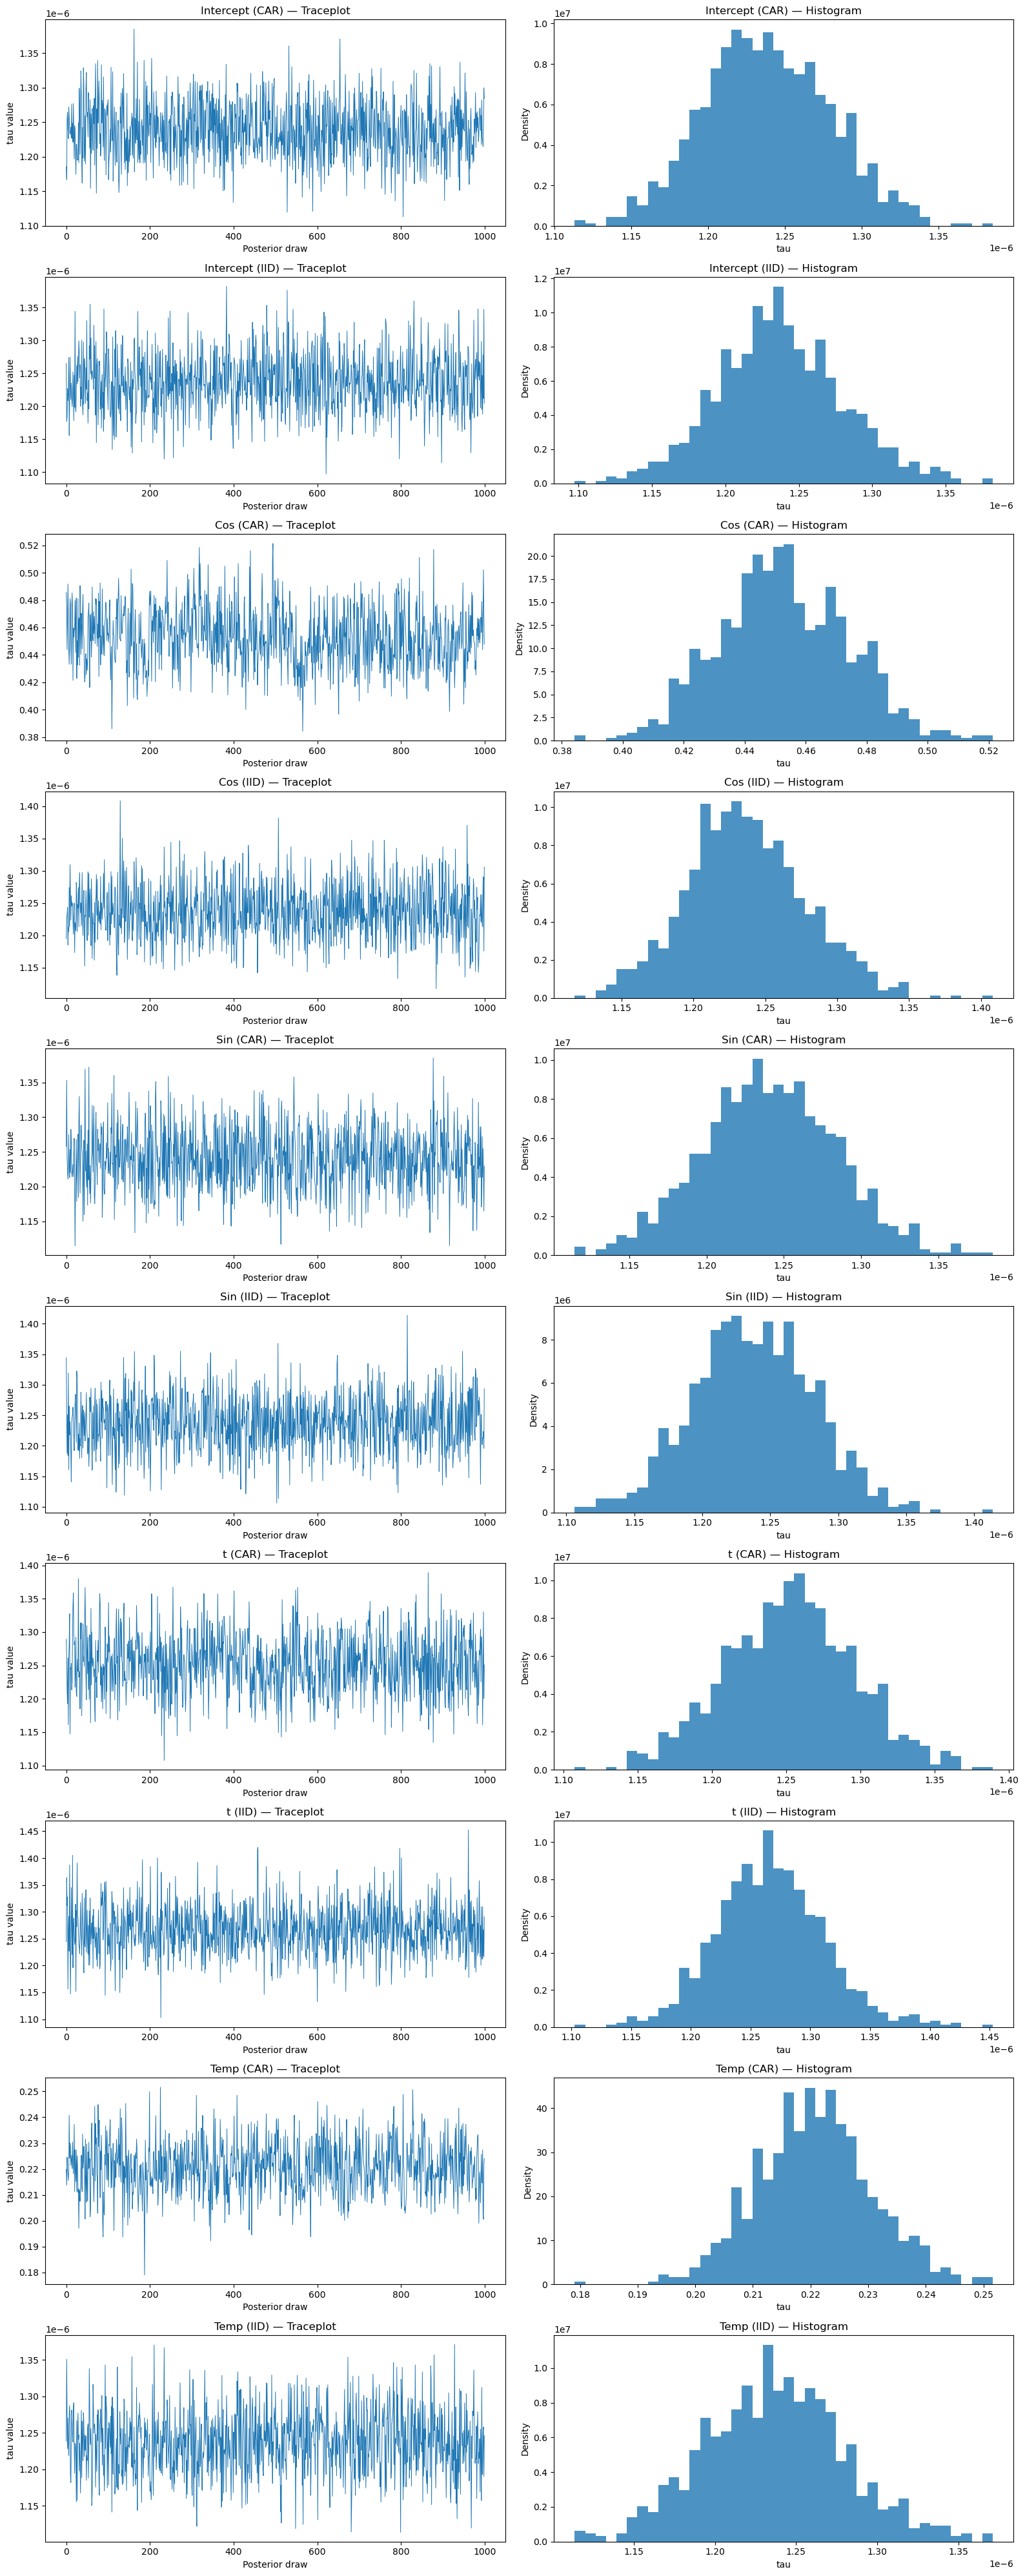

In [5]:
import matplotlib.pyplot as plt
import numpy as np


K, nsamp = all_tau.shape

tau_names = [
    "Intercept (CAR)",
    "Intercept (IID)",
    "Cos (CAR)",
    "Cos (IID)",
    "Sin (CAR)",
    "Sin (IID)",
    "t (CAR)",
    "t (IID)",
    "Temp (CAR)",
    "Temp (IID)"
]

plt.figure(figsize=(16, 4 * K))

plot_idx = 1

for j in range(K):

    tau_j = all_tau[j,:]

    # ===== Traceplot =====
    ax1 = plt.subplot(K, 2, plot_idx)
    ax1.plot(tau_j, linewidth=0.7)
    ax1.set_title(f"{tau_names[j]} — Traceplot")
    ax1.set_xlabel("Posterior draw")
    ax1.set_ylabel("tau value")
    
    plot_idx += 1

    # ===== Histogram =====
    ax2 = plt.subplot(K, 2, plot_idx)
    ax2.hist(tau_j, bins=40, density=True, alpha=0.8)
    ax2.set_title(f"{tau_names[j]} — Histogram")
    ax2.set_xlabel("tau")
    ax2.set_ylabel("Density")

    plot_idx += 1

plt.tight_layout()
plt.show()


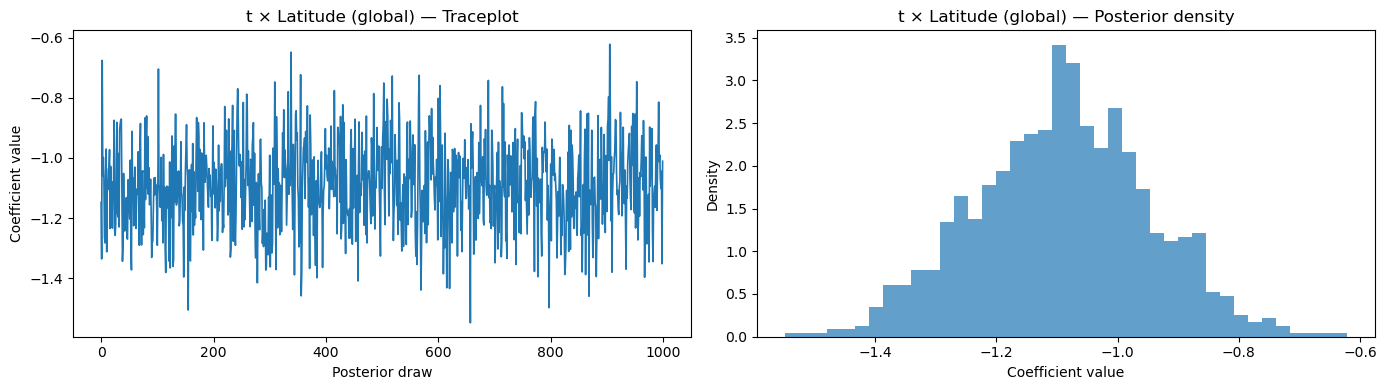

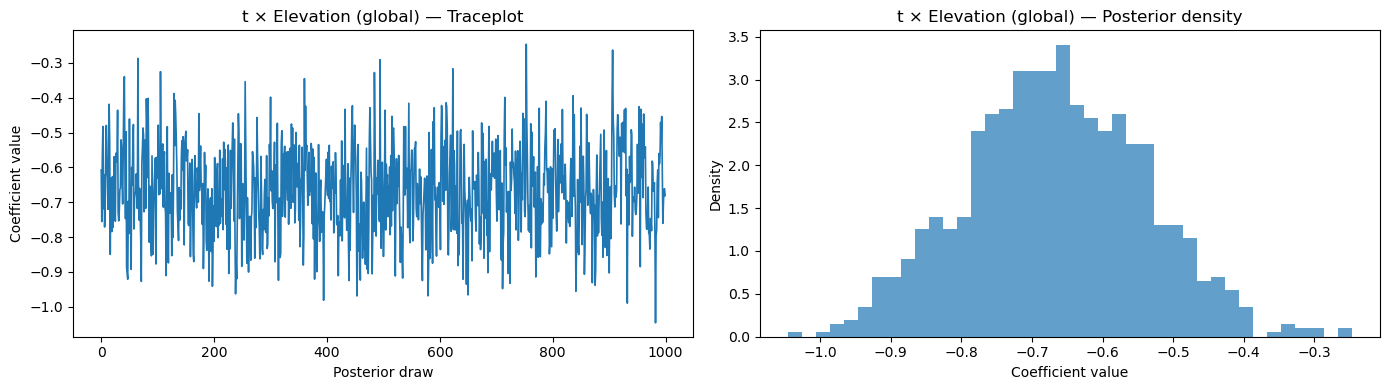

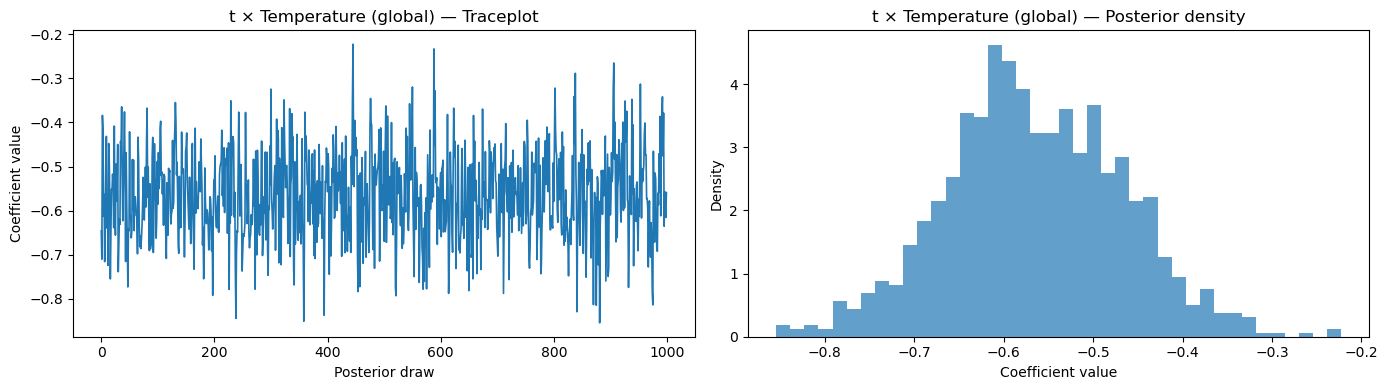

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# --------------------------------------------------
# Load posterior samples
# --------------------------------------------------
res = np.load(r"D:\77\Research\temp\snow\bym++01.npz")
all_theta = res["all_theta"]    # (theta_dim, nSamples)

n_samples = all_theta.shape[1]
S = 1618   

# --------------------------------------------------
# Correct indices for BYM+ global interactions
# --------------------------------------------------
global_start = 8 * S

lat_idx  = global_start + 0     # t × latitude
elev_idx = global_start + 1     # t × elevation
temp_idx = global_start + 2     # t × temperature

lat_trace  = all_theta[lat_idx, :]
elev_trace = all_theta[elev_idx, :]
temp_trace = all_theta[temp_idx, :]

# --------------------------------------------------
# Plot helper
# --------------------------------------------------
def plot_trace_and_hist(trace, name):
    fig, ax = plt.subplots(1, 2, figsize=(14, 4))

    # Trace
    ax[0].plot(trace, lw=1.2)
    ax[0].set_title(f"{name} — Traceplot")
    ax[0].set_xlabel("Posterior draw")
    ax[0].set_ylabel("Coefficient value")

    # Histogram
    ax[1].hist(trace, bins=40, density=True, alpha=0.7)
    ax[1].set_title(f"{name} — Posterior density")
    ax[1].set_xlabel("Coefficient value")
    ax[1].set_ylabel("Density")

    plt.tight_layout()
    plt.show()

# --------------------------------------------------
# Plot the three global interactions
# --------------------------------------------------
plot_trace_and_hist(lat_trace,  "t × Latitude (global)")
plot_trace_and_hist(elev_trace, "t × Elevation (global)")
plot_trace_and_hist(temp_trace, "t × Temperature (global)")


In [6]:
import numpy as np
import arviz as az

# -----------------------------------
# load posterior samples
# -----------------------------------
res = np.load(r"D:\77\Research\temp\snow\bym++10.npz")
all_theta = res["all_theta"]      # (theta_dim, nSamples)

S = 1618
global_start = 8 * S

lat_trace  = all_theta[global_start + 0, :]
elev_trace = all_theta[global_start + 1, :]
temp_trace = all_theta[global_start + 2, :]

# -----------------------------------
# wrap as InferenceData (1 chain)
# -----------------------------------
idata = az.from_dict(
    posterior={
        "t_lat":  lat_trace[None, :],   # shape = (chain=1, draw)
        "t_elev": elev_trace[None, :],
        "t_temp": temp_trace[None, :]
    }
)

# -----------------------------------
# compute ESS
# -----------------------------------
ess = az.ess(idata, method="bulk")

print("\n=========== Effective Sample Size (ESS) ===========")
for v in ess.data_vars:
    print(f"{v:8s} : ESS = {float(ess[v]):.1f}")
print("===================================================")


e:\anaconda3\envs\CPD\Lib\site-packages\arviz\__init__.py:39: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(
e:\anaconda3\envs\CPD\Lib\site-packages\cupy\_environment.py:215: UserWarning: CUDA path could not be detected. Set CUDA_PATH environment variable if CuPy fails to load.
  warnings.warn(



=========== Effective Sample Size (ESS) ===========
t_lat    : ESS = 1046.6
t_elev   : ESS = 716.8
t_temp   : ESS = 788.7
